# 001. Análisis Exploratorio Inicial y Diagnóstico de Calidad de Datos (EDA Nivel Experto)

**Proyecto:** Análisis de Licitaciones Públicas de Chile (`Licitaciones`)  
**Archivo Fuente:** `data/raw/Licitacion.csv` (~588 MB, 471.7k registros, 46 columnas)

---

## 🎯 Objetivo del Notebook
Este notebook realiza una **exploración inicial de alto nivel**, realizando conjeturas, diagnósticos de calidad, verificaciones cruzadas y análisis de alcance para formular un **plan de limpieza y procesamiento óptimo** que se ejecutará en las etapas posteriores (`02_limpieza_y_procesamiento.ipynb`).

---


## 1. Carga del Dataset y Diagnóstico de Estructura e Integridad

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

raw_path = '../data/raw/Licitacion.csv'

# Carga del dataset con encoding latin-1
df = pd.read_csv(raw_path, sep=';', encoding='latin-1', low_memory=False)

print(f"Dimensiones Totales: {df.shape[0]:,} filas x {df.shape[1]} columnas.")
print(f"Uso de Memoria RAM Aproximado: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
df.head(3)


Dimensiones Totales: 471,748 filas x 46 columnas.


Uso de Memoria RAM Aproximado: 1709.86 MB


,codigoOC,NroLicitacion,FechaEnvioOC,NombreOC,DescripcionOC,EstadoOC,ProcedenciaOC,CompraCoordinada,MonedaOC,MontoNetoOC,...,DescripcionItem,CantidadItem,UnidadMedida,MonedaItem,MontoNetoItem,DescuentoItem,CargosItem,ImpuestoEspecificoItem,MontoTotalItem,MontoNetoItemCLP
0,2102-544-SE25,2102-50-LE23,24-06-2025 0:00:00,MANTENCION PREVENTIVA Ý CORRECTIVA DE EQUIPAMI...,MANTENCION PREVENTIVA Ý CORRECTIVA DE EQUIPAMI...,Recepcion Conforme,Licitacion Publica,No,CLP,1500000,...,"MANTENCION CORRECTIVA, BATERIA Desfibrilador Z...",1,Unidad,CLP,1500000,0,0,0,1500000,1500000
1,1057420-516-SE25,1057420-21-LE25,13-06-2025 0:00:00,LP- ADQUISICION BOBINA ESTERILIZACION-ITEM 22....,*FAVOR COMPLEMENTAR DESPACHO CON OC N°1057420-...,Recepcion Conforme,Licitacion Publica,No,CLP,307500,...,Rollo esterilización papel bilaminado (para au...,15,Unidad,CLP,20500,0,0,0,307500,307500
2,813-958-SE25,813-36-LQ24,19-06-2025 0:00:00,Emision PP 48.2024 Mihovilovic,PP 48 Material Laboratorio ANAMED DESDE 813-36...,Recepcion Conforme,Licitacion Publica,No,CLP,16824530,...,(ID 4098) ITEM:138 DESCRIPCION: Tubo tipo eppe...,2,Unidad,CLP,12000,0,0,0,24000,24000


## 2. Inspección de Tipos de Datos y Detección de Duplicados

In [2]:
# 1. Conteo de tipos de datos
print("=== Distribución de Tipos de Datos ===")
print(df.dtypes.value_counts())

# 2. Duplicados exactos vs Duplicados por clave de Orden de Compra (codigoOC)
dup_exactos = df.duplicated().sum()
dup_oc = df.duplicated(subset=['codigoOC']).sum()
total_oc_unicas = df['codigoOC'].nunique()

print(f"\nDuplicados exactos en el dataset: {dup_exactos:,}")
print(f"Órdenes de Compra (codigoOC) únicas: {total_oc_unicas:,}")
print(f"Registros de items totales asociados a OCs: {df.shape[0]:,}")
print(f"Promedio de items por Orden de Compra: {df.shape[0] / total_oc_unicas:.2f} items/OC")


=== Distribución de Tipos de Datos ===
object    43
int64      3
Name: count, dtype: int64



Duplicados exactos en el dataset: 968
Órdenes de Compra (codigoOC) únicas: 201,831
Registros de items totales asociados a OCs: 471,748
Promedio de items por Orden de Compra: 2.34 items/OC


## 3. Diagnóstico de Valores Faltantes (Missing Values) y Pruebas de Imputación

En esta sección evaluamos la presencia de valores nulos y ponemos a prueba nuestras conjeturas de imputación mediante cruzamiento de llaves unívocas.


In [3]:
# Resumen de Nulos
nulos_summary = pd.DataFrame({
    'Total_Nulos': df.isnull().sum(),
    'Porcentaje_Nulos': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Total_Nulos', ascending=False)

print("=== Columnas con Valores Nulos ===")
print(nulos_summary[nulos_summary['Total_Nulos'] > 0])


=== Columnas con Valores Nulos ===
                    Total_Nulos  Porcentaje_Nulos
Financiamiento           377057         79.927631
ActividadProveedor        30984          6.567913
RegionUnidadCompra        15328          3.249192
RegionProveedor            6358          1.347753
DescripcionItem            4446          0.942452
DescripcionOC               689          0.146053
MontoNetoOC_CLP              17          0.003604
ImpuestosOC_CLP              17          0.003604
MontoNetoItemCLP             17          0.003604
MontoTotalItem               13          0.002756


### 💡 Conjetura 1: Imputación de Regiones Compradoras y Proveedoras por RUT
**Hipótesis:** Una institución compradora (`UnidadCompraRUT`) o un proveedor (`ProveedorRUT`) opera predominantemente en una misma región. Si existe una fila con región nula pero la entidad aparece en otras filas con su región informada, podemos imputar el valor faltante con un mapeo directo por RUT.


In [4]:
# Test de Conjetura 1: Cobertura de imputación por RUT
# 1. Región Unidad Compra
uc_con_region = df.dropna(subset=['UnidadCompraRUT', 'RegionUnidadCompra']).drop_duplicates(subset=['UnidadCompraRUT'])
mapa_uc = uc_con_region.set_index('UnidadCompraRUT')['RegionUnidadCompra'].to_dict()

nulos_uc_inicial = df['RegionUnidadCompra'].isnull().sum()
imputables_uc = df[df['RegionUnidadCompra'].isnull()]['UnidadCompraRUT'].map(mapa_uc).notnull().sum()

# 2. Región Proveedor
prov_con_region = df.dropna(subset=['ProveedorRUT', 'RegionProveedor']).drop_duplicates(subset=['ProveedorRUT'])
mapa_prov = prov_con_region.set_index('ProveedorRUT')['RegionProveedor'].to_dict()

nulos_prov_inicial = df['RegionProveedor'].isnull().sum()
imputables_prov = df[df['RegionProveedor'].isnull()]['ProveedorRUT'].map(mapa_prov).notnull().sum()

print("="*60)
print(f"RegionUnidadCompra Nulos Iniciales: {nulos_uc_inicial:,}")
print(f"RegionUnidadCompra Imputables por RUT: {imputables_uc:,} ({imputables_uc/nulos_uc_inicial*100:.1f}%)")
print(f"RegionProveedor Nulos Iniciales:     {nulos_prov_inicial:,}")
print(f"RegionProveedor Imputables por RUT:     {imputables_prov:,} ({imputables_prov/nulos_prov_inicial*100:.1f}%)")
print("="*60)


RegionUnidadCompra Nulos Iniciales: 15,328
RegionUnidadCompra Imputables por RUT: 15,328 (100.0%)
RegionProveedor Nulos Iniciales:     6,358
RegionProveedor Imputables por RUT:     5,662 (89.1%)


## 4. Diagnóstico de Formatos Numéricos, Separadores Decimales y Fechas

In [5]:
# 1. Verificación de separadores decimales (uso de comas en cadenas texto)
cols_numericas_raw = ['CantidadItem', 'MontoNetoItem', 'MontoTotalOC', 'MontoTotalItem']

print("=== Muestra de Valores Crudos Numéricos ===")
for col in cols_numericas_raw:
    muestra = df[col].dropna().astype(str).head(3).tolist()
    tiene_coma = df[col].dropna().astype(str).str.contains(',').any()
    print(f"Columna '{col}': tiene comas = {tiene_coma} -> Muestra: {muestra}")

# 2. Verificación de Fechas
df['FechaEnvioOC_dt'] = pd.to_datetime(df['FechaEnvioOC'], format='%d-%m-%Y %H:%M:%S', errors='coerce')

print("\n=== Análisis de Rango Temporal ===")
print(f"Fecha Mínima: {df['FechaEnvioOC_dt'].min()}")
print(f"Fecha Máxima: {df['FechaEnvioOC_dt'].max()}")
print(f"Fechas Nulas o Malformadas: {df['FechaEnvioOC_dt'].isnull().sum():,}")


=== Muestra de Valores Crudos Numéricos ===
Columna 'CantidadItem': tiene comas = True -> Muestra: ['1', '15', '2']
Columna 'MontoNetoItem': tiene comas = True -> Muestra: ['1500000', '20500', '12000']


Columna 'MontoTotalOC': tiene comas = True -> Muestra: ['1785000', '365925', '20021190,7']
Columna 'MontoTotalItem': tiene comas = True -> Muestra: ['1500000', '307500', '24000']

=== Análisis de Rango Temporal ===
Fecha Mínima: 2025-01-01 00:00:00
Fecha Máxima: 2025-06-30 00:00:00
Fechas Nulas o Malformadas: 0


## 5. Análisis Multimoneda y Conjetura de Homologación a CLP

**Hipótesis:** Existen transacciones en distintas divisas (`CLP`, `USD`, `CLF`/`UF`). Para comparar montos de forma precisa, se requiere convertir todas las compras a una moneda común (`CLP`) utilizando el tipo de cambio del día o tasas históricas representativas.


=== Distribución de Monedas en Orden de Compra (MonedaOC) ===
MonedaOC
CLP    470727
USD       860
CLF       161
Name: count, dtype: int64

=== Distribución de Monedas por Item (MonedaItem) ===
MonedaItem
CLP    470731
USD       856
CLF       161
Name: count, dtype: int64


/var/folders/lm/yp2bpkn50pq0684gph652lgr0000gn/T/ipykernel_9907/1616418215.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='MonedaItem', palette='Set2')


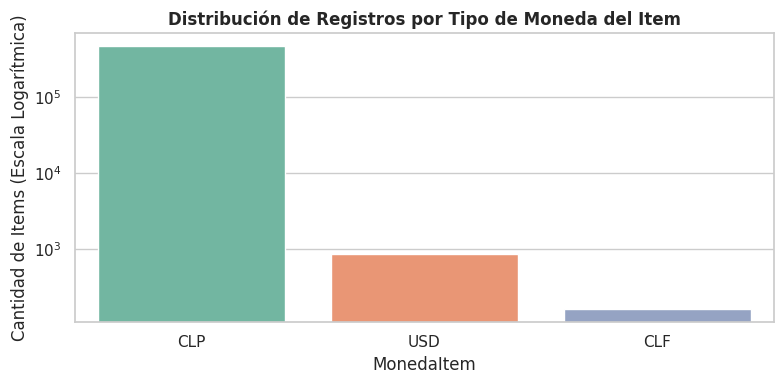

In [6]:
dist_moneda_oc = df['MonedaOC'].value_counts(dropna=False)
dist_moneda_item = df['MonedaItem'].value_counts(dropna=False)

print("=== Distribución de Monedas en Orden de Compra (MonedaOC) ===")
print(dist_moneda_oc)

print("\n=== Distribución de Monedas por Item (MonedaItem) ===")
print(dist_moneda_item)

# Visualización
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='MonedaItem', palette='Set2')
plt.title('Distribución de Registros por Tipo de Moneda del Item', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.ylabel('Cantidad de Items (Escala Logarítmica)')
plt.tight_layout()
plt.show()


## 6. Selección de Atributos y Plan de Reducción Dimensional

De las 46 columnas originales, identificamos columnas redundantes, constantes o con nulos masivos (como `Financiamiento` con >79% nulos) que pueden descartarse.

### Alcance de Selección de Columnas para Notebook 02:
1. **Identificadores y Fechas:** `codigoOC`, `FechaEnvioOC`
2. **Atributos de Contratación:** `EstadoOC`, `ProcedenciaOC`, `MontoTotalOC`, `MonedaOC`
3. **Comprador:** `UnidadCompra`, `UnidadCompraRUT`, `RegionUnidadCompra`
4. **Proveedor:** `Proveedor`, `ProveedorRUT`, `TamanoProveedor`, `RegionProveedor`
5. **Categoría Producto ONU:** `RubroN1`, `RubroN2`, `RubroN3`, `CodigoProductoONU`, `ONUProducto`
6. **Detalle del Item:** `CantidadItem`, `MontoNetoItem`, `UnidadMedida`, `MonedaItem`


In [7]:
cols_seleccionadas = [
    'codigoOC', 'FechaEnvioOC', 'EstadoOC', 'ProcedenciaOC', 'MontoTotalOC', 'MonedaOC',
    'UnidadCompra', 'UnidadCompraRUT', 'RegionUnidadCompra',
    'Proveedor', 'ProveedorRUT', 'TamanoProveedor', 'RegionProveedor',
    'RubroN1', 'RubroN2', 'RubroN3', 'CodigoProductoONU', 'ONUProducto',
    'CantidadItem', 'MontoNetoItem', 'UnidadMedida', 'MonedaItem'
]

df_sub = df[cols_seleccionadas]
mem_original = df.memory_usage(deep=True).sum() / (1024**2)
mem_reducida = df_sub.memory_usage(deep=True).sum() / (1024**2)

print("="*60)
print(f"Columnas Originales: 46  ->  Columnas Seleccionadas: {len(cols_seleccionadas)}")
print(f"Memoria RAM Original:  {mem_original:.2f} MB")
print(f"Memoria RAM Reducida:   {mem_reducida:.2f} MB (Ahorro del {100 - (mem_reducida/mem_original*100):.1f}%)")
print("="*60)


Columnas Originales: 46  ->  Columnas Seleccionadas: 22
Memoria RAM Original:  1796.68 MB
Memoria RAM Reducida:   809.58 MB (Ahorro del 54.9%)


## 7. Síntesis Master y Conjeturas Finales para la Limpieza Óptima

A partir de la exploración realizada en este notebook `001_exploracion_inicial.ipynb`, se establecen las siguientes directrices obligatorias para el procesamiento en el **Notebook 02**:

| Aspecto | Diagnóstico Detectado | Acción y Conjetura de Solución |
| :--- | :--- | :--- |
| **Separadores Decimales** | `CantidadItem` y `MontoNetoItem` vienen como texto con `,`. | Reemplazar `,` por `.` y castear a `float64`. |
| **Columna Total** | Existen algunos nulos en `MontoTotalItem`. | Recalcular como `TotalItem = CantidadItem * MontoNetoItem`. |
| **Imputación Geográfica** | Regiones con nulos (`RegionUnidadCompra`, `RegionProveedor`). | Imputar creando diccionarios unívocos por `UnidadCompraRUT` y `ProveedorRUT`. El saldo no imputable se asigna a `'No Especificada'`. |
| **Homologación Divisas** | Existen transacciones en `USD` y `CLF/UF`. | Consultar API `mindicador.cl` o usar matriz de tipos de cambio históricos para convertir a `MontoNetoItemCLP`, `TotalItemCLP` y `MontoTotalOCCLP`. |
| **Formato de Fechas** | `FechaEnvioOC` viene como string con hora `0:00:00`. | Castear a `datetime64[ns]` y normalizar a nivel de día. |
| **Formato de Salida** | Archivo CSV crudo es pesado (588 MB) y lento de leer. | Exportar dataset limpio en formato **Parquet** en `data/processed/Licitacion_procesada.parquet` (compresión ultra eficiente). |
